In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [3]:
df = pd.read_csv(r"C:\Users\hp\Documents\Oasis Infobyte Tasks or Projects Documents\Task 5\Task 5 Documents\extracted csv\Housing.csv")

In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
# Check the number of rows and columns
print("Dataset shape:", df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Check data types
print("\nData types:")
print(df.dtypes)

Dataset shape: (545, 13)

Column names:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Data types:
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object


In [6]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [7]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [8]:
# Display summary statistics for numerical columns
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [9]:
# Identify numerical and categorical columns

numerical_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(include="object").columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

Categorical features:
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


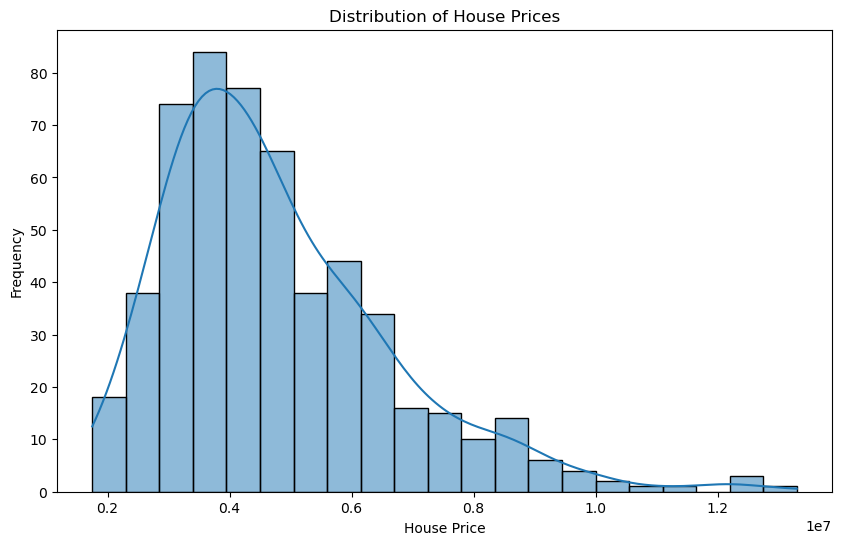

In [10]:
# Distribution of house prices

plt.figure(figsize=(10, 6))

sns.histplot(df["price"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.show()

### Feature Selection Discussion

The target variable for this project is `price`, which represents the selling price of the house.

Potential predictors include `area`, `bedrooms`, `bathrooms`, `stories`, and `parking`. Larger houses with greater area, more bathrooms, bedrooms, stories, and parking spaces may have higher prices.

The categorical features such as `mainroad`, `guestroom`, `basement`, `airconditioning`, `prefarea`, and `furnishingstatus` may also influence house prices. These categorical variables will be converted into numerical form using One-Hot Encoding before training the regression model.

The final selection of features will be supported by exploratory analysis and correlation analysis.

### Missing Value Handling

The dataset was checked for missing values, and no missing values were found in any of the columns. Therefore, no imputation or removal of rows was necessary.

In [11]:
# Verify missing values
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [12]:
# Create a copy of the dataset for preprocessing
df_encoded = df.copy()

# Apply One-Hot Encoding to categorical variables
df_encoded = pd.get_dummies(
    df_encoded,
    columns=categorical_features,
    drop_first=True
)

# Display the first 5 rows
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [13]:
print("Original dataset shape:", df.shape)
print("Encoded dataset shape:", df_encoded.shape)

print("\nEncoded columns:")
print(df_encoded.columns.tolist())

Original dataset shape: (545, 13)
Encoded dataset shape: (545, 14)

Encoded columns:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


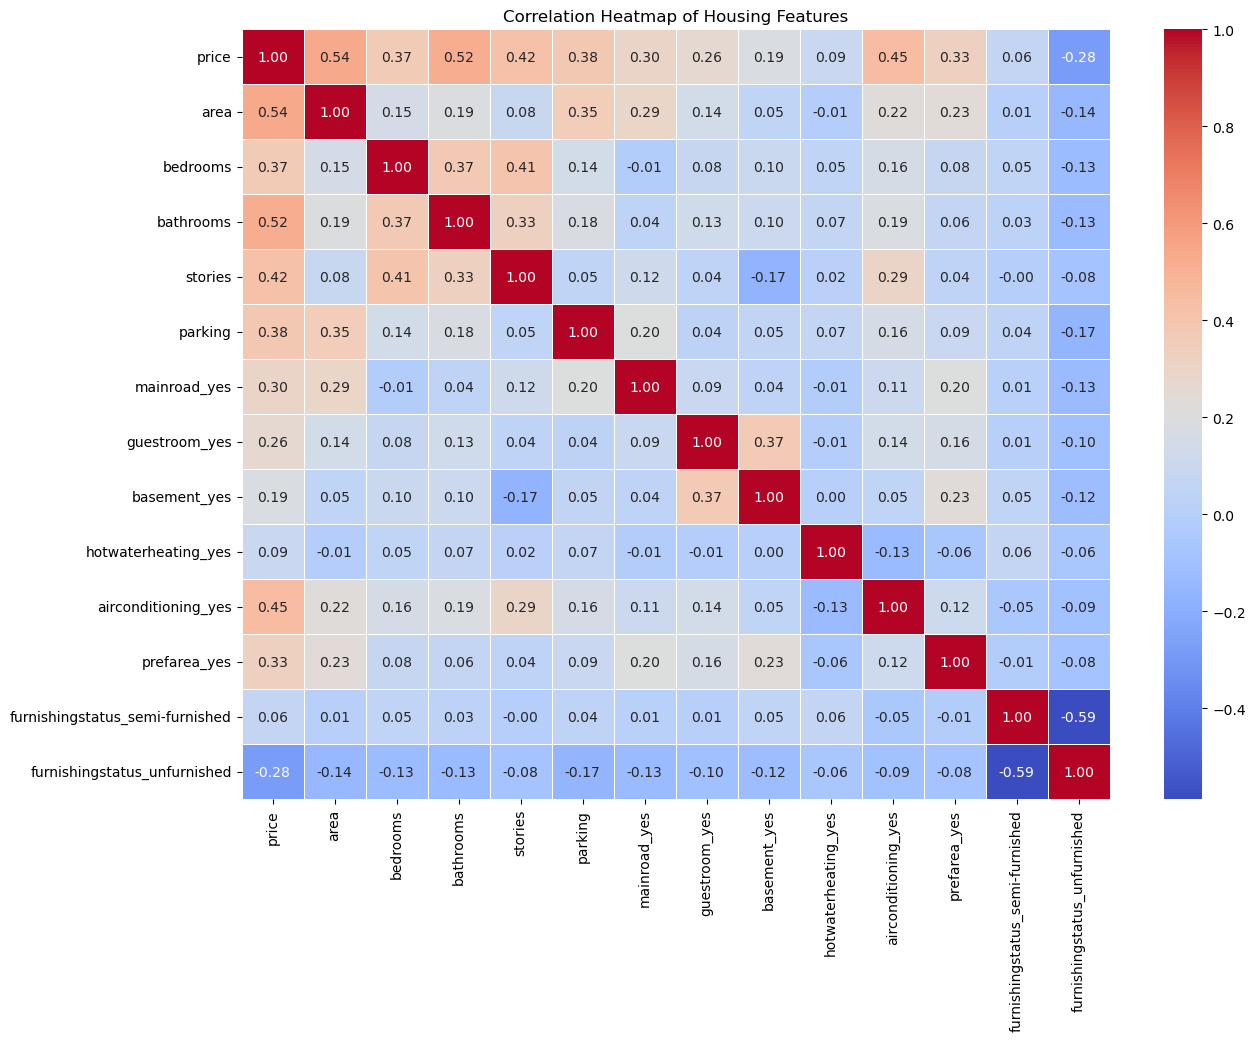

In [14]:
# Calculate correlation matrix
correlation_matrix = df_encoded.corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Housing Features")
plt.show()

### Correlation Analysis

The correlation heatmap shows the relationships between the numerical and encoded categorical features and the target variable, `price`.

The `area` variable has a relatively strong positive correlation with house price, indicating that houses with larger areas tend to have higher prices. Other variables such as `bathrooms`, `stories`, and `parking` also show positive relationships with price.

The correlation values provide an initial indication of which features may be useful for predicting house prices. However, correlation alone does not establish causation, and the regression model will be used to evaluate the combined predictive contribution of the features.

### Feature and Target Separation

The target variable for the regression model is `price`. All remaining numerical and encoded categorical variables are used as predictor features.

In [15]:
# Separate features and target variable

X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (545, 13)
Target shape: (545,)


In [16]:
from sklearn.model_selection import train_test_split

# Split the dataset into 80% training and 20% testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (436, 13)
Testing features: (109, 13)
Training target: (436,)
Testing target: (109,)


### Train-Test Split

The dataset was divided into training and testing sets using an 80/20 split. The training set contains 80% of the observations and is used to train the Linear Regression model, while the remaining 20% is reserved for evaluating the model's performance on unseen data.

A fixed random state of 42 was used to ensure that the same split can be reproduced.

In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
# Create the Linear Regression model

linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [19]:
# Make predictions on the test dataset

y_pred = linear_model.predict(X_test)

# Display the first 10 predictions
print("First 10 predicted prices:")
print(y_pred[:10])

First 10 predicted prices:
[5164653.90033967 7224722.29802167 3109863.24240338 4612075.32722559
 3294646.25725955 3532275.09556558 5611774.56836476 6368145.98732718
 2722856.95689985 2629405.61585782]


In [20]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate evaluation metrics

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Model Evaluation:
Mean Squared Error (MSE): 1754318687330.66
Root Mean Squared Error (RMSE): 1324506.96
R² Score: 0.6529


### Model Evaluation

The Linear Regression model is evaluated using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R².

- **MSE** measures the average squared difference between the actual and predicted prices.
- **RMSE** represents the typical prediction error in the same units as the target variable.
- **R²** indicates how much of the variation in house prices is explained by the model.

A higher R² value indicates better explanatory performance, while lower MSE and RMSE indicate smaller prediction errors.

In [22]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²) Score: {r2:.4f}")

Model Evaluation:
Mean Squared Error (MSE): 1754318687330.66
Root Mean Squared Error (RMSE): 1324506.96
R-squared (R²) Score: 0.6529


### Actual vs. Predicted House Prices

The actual versus predicted scatter plot compares the prices observed in the test dataset with the prices predicted by the Linear Regression model. A model with stronger predictive performance would have points concentrated around the diagonal reference line, where predicted prices are close to actual prices.

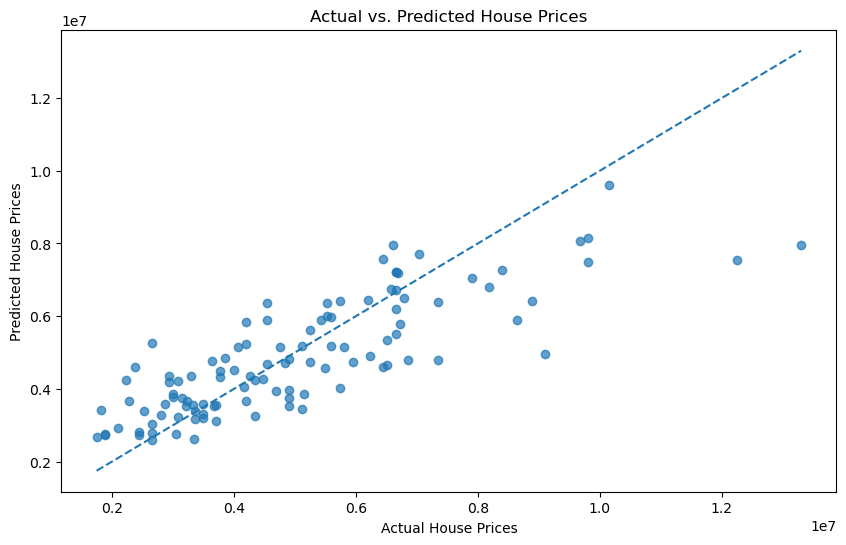

In [23]:
# Actual vs Predicted House Prices

plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

# Reference line: perfect predictions
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Actual vs. Predicted House Prices")
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")

plt.show()

In [24]:
# Calculate residuals

residuals = y_test - y_pred

# Display the first 10 residuals
print("First 10 residuals:")
print(residuals[:10])

First 10 residuals:
316   -1.104654e+06
77    -5.747223e+05
360    6.001368e+05
90     1.827925e+06
493   -4.946463e+05
209    1.367725e+06
176   -3.617746e+05
249   -1.825146e+06
516   -2.728570e+05
426    7.235944e+05
Name: price, dtype: float64


### Residual Analysis

Residuals represent the difference between the actual house prices and the prices predicted by the Linear Regression model.

A residual plot helps assess whether the model's errors are randomly distributed around zero. A reasonably random pattern around the zero line suggests that the model has captured the main relationship between the predictors and the target variable. Clear patterns or increasing spread may indicate that the model does not fully capture the underlying relationship.

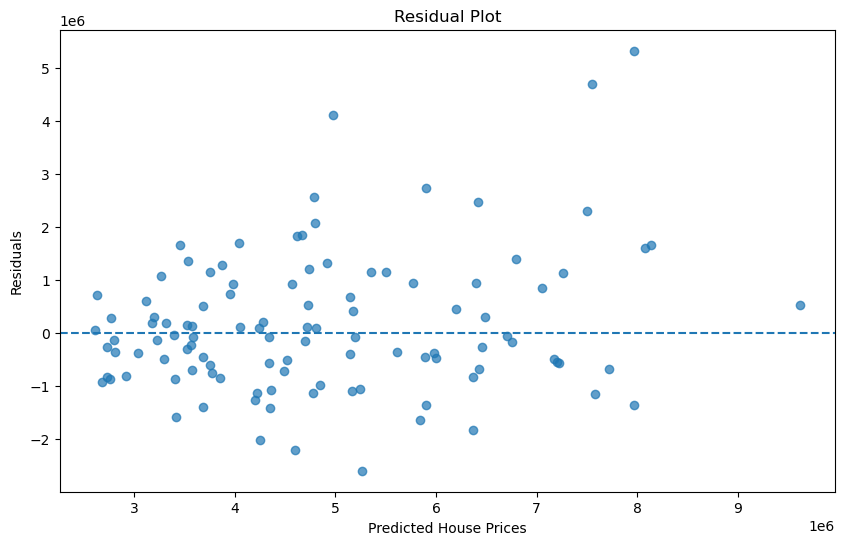

In [25]:
# Residual plot

plt.figure(figsize=(10, 6))

plt.scatter(y_pred, residuals, alpha=0.7)

# Zero reference line
plt.axhline(y=0, linestyle="--")

plt.title("Residual Plot")
plt.xlabel("Predicted House Prices")
plt.ylabel("Residuals")

plt.show()

In [26]:
# Create a DataFrame containing feature coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

# Sort by absolute coefficient value
coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient,Absolute_Coefficient
2,bathrooms,1.094445e+06,1.094445e+06
9,airconditioning_yes,7.914267e+05,7.914267e+05
8,hotwaterheating_yes,6.846499e+05,6.846499e+05
10,prefarea_yes,6.298906e+05,6.298906e+05
12,furnishingstatus_unfurnished,-4.136451e+05,4.136451e+05
3,stories,4.074766e+05,4.074766e+05
7,basement_yes,3.902512e+05,3.902512e+05
5,mainroad_yes,3.679199e+05,3.679199e+05
6,guestroom_yes,2.316100e+05,2.316100e+05
4,parking,2.248419e+05,2.248419e+05


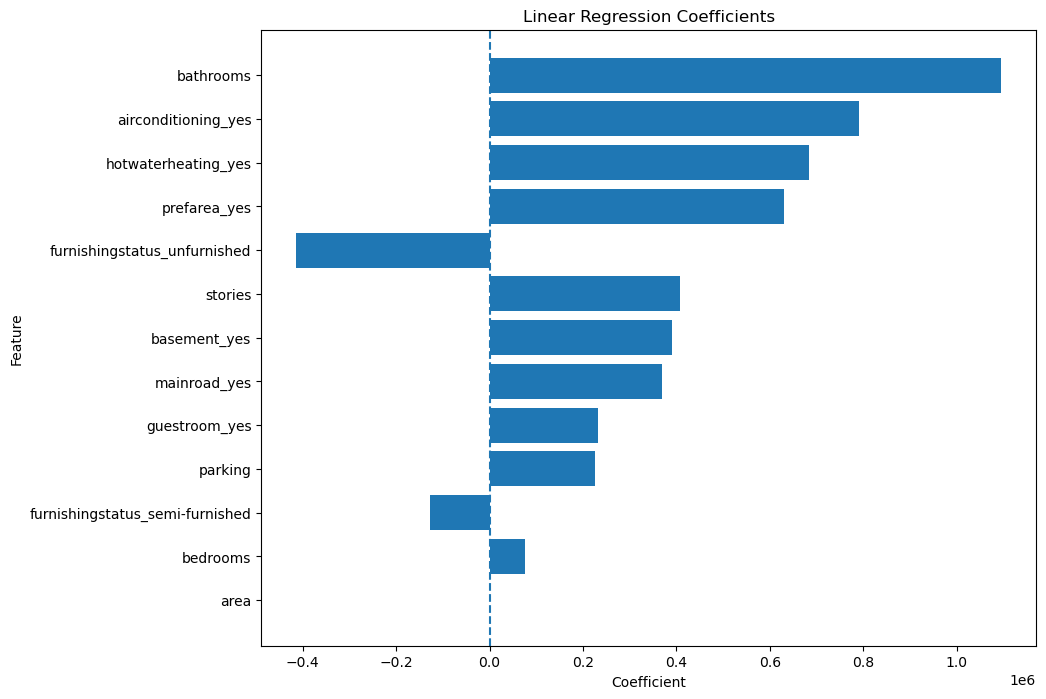

In [27]:
# Plot regression coefficients

plt.figure(figsize=(10, 8))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.axvline(x=0, linestyle="--")

plt.title("Linear Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

### Coefficient Analysis

The regression coefficients indicate the estimated effect of each feature on house price while holding the other features constant.

Positive coefficients indicate that an increase or presence of the corresponding feature is associated with an increase in the predicted house price, while negative coefficients indicate an association with a decrease in predicted price.

The magnitude of a coefficient should be interpreted in the context of the feature's units and encoding. Therefore, coefficients with different units should not be compared directly without considering their scales.

## Final Model Interpretation

The Linear Regression model achieved an R² score of 0.6529 on the test dataset. This means that approximately 65.29% of the variation in house prices is explained by the features included in the model.

The model produced a Mean Squared Error (MSE) of 1,754,318,687,330.66 and a Root Mean Squared Error (RMSE) of 1,324,506.96. The RMSE indicates that the model's predictions differ from the actual house prices by approximately 1.32 million price units on average in terms of the typical prediction error.

The actual-versus-predicted plot provides a visual comparison between the model's predictions and the observed prices. The residual plot is used to examine whether the prediction errors are distributed randomly around zero.

Overall, the Linear Regression model provides a reasonable baseline for predicting house prices, although approximately 34.71% of the variation remains unexplained. More advanced regression techniques or additional relevant features could potentially improve predictive performance.

# Conclusion

In this project, a Linear Regression model was developed to predict house prices using numerical and categorical housing features.

The dataset was explored and checked for missing values and duplicates. Categorical variables were converted into numerical representations using One-Hot Encoding. A correlation heatmap was used to examine relationships between the features and house prices.

The dataset was divided into training and testing sets using an 80/20 split. The Linear Regression model was trained on the training data and evaluated on the test data using MSE, RMSE, and R².

The model achieved an R² score of 0.6529, indicating that it explains approximately 65.29% of the variation in house prices. The actual-versus-predicted and residual plots were also used to evaluate the model visually.

Overall, the project demonstrates how exploratory data analysis, preprocessing, feature engineering, and Linear Regression can be combined to build a basic house-price prediction model.

In [28]:
from sklearn.linear_model import Ridge, Lasso

In [29]:
# Create Ridge and Lasso models

ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=1.0)

# Train the models
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

print("Ridge and Lasso models trained successfully.")

Ridge and Lasso models trained successfully.


In [30]:
# Make predictions

ridge_pred = ridge_model.predict(X_test)
lasso_pred = lasso_model.predict(X_test)

In [31]:
# Calculate evaluation metrics for all three models

linear_mse = mean_squared_error(y_test, y_pred)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, y_pred)

ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

# Create comparison table
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "MSE": [linear_mse, ridge_mse, lasso_mse],
    "RMSE": [linear_rmse, ridge_rmse, lasso_rmse],
    "R²": [linear_r2, ridge_r2, lasso_r2]
})

model_comparison

,Model,MSE,RMSE,R²
0,Linear Regression,1.754319e+12,1.324507e+06,0.652924
1,Ridge Regression,1.756474e+12,1.325320e+06,0.652498
2,Lasso Regression,1.754321e+12,1.324508e+06,0.652924


## Ridge and Lasso Regression Comparison

Ridge and Lasso Regression were tested as regularized alternatives to the standard Linear Regression model.

Ridge Regression applies L2 regularization, which reduces the magnitude of the model coefficients and can help when predictors are correlated.

Lasso Regression applies L1 regularization, which can reduce some coefficients toward zero and can therefore perform a degree of feature selection.

The three models can be compared using MSE, RMSE, and R². A model with lower MSE and RMSE and a higher R² provides better predictive performance on the test dataset.

The model comparison results can be used to determine whether regularization provides an improvement over the standard Linear Regression baseline.

## Ridge and Lasso Regression Comparison

Ridge and Lasso Regression were compared with the baseline Linear Regression model.

The Linear Regression model achieved the lowest MSE and RMSE and the highest R² score among the three models. Lasso Regression produced almost identical results, while Ridge Regression performed slightly worse.

The results indicate that regularization did not provide a meaningful improvement over standard Linear Regression for this dataset. Therefore, Linear Regression is selected as the final model because it provides the best overall performance among the models tested.